In [ ]:
# importing libraries
import os
import torch
import torchvision
import tarfile
# import py7zr
from torchvision.datasets.utils import download_url
from torch.utils.data import random_split
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor,ToPILImage
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from torch.utils.data.dataloader import DataLoader
from torchvision.utils import make_grid
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
# Extract from tar archive file
with tarfile.open('/content/drive/MyDrive/cifar10.tgz', 'r:gz') as tar:
    tar.extractall(path='/content/drive/MyDrive/input')

print("Extraction completed successfully!")


Extraction completed successfully!


In [ ]:
print(os.listdir('/content/drive/MyDrive/input/cifar10'))
classes= os.listdir('/content/drive/MyDrive/input/cifar10/train')
print(classes)

['train']
['dog', 'automobile', 'ship', 'frog', 'airplane', 'truck', 'cat']


In [ ]:
cat_files= os.listdir('/content/drive/MyDrive/input/cifar10/train/cat')
print('No of training example for cats:',len(cat_files))
print(cat_files[:5])

No of training example for cats: 5000
['6351_cat.png', '13287_cat.png', '11458_cat.png', '47840_cat.png', '32794_cat.png']


In [ ]:
automobile_files= os.listdir('/content/drive/MyDrive/input/cifar10/train/automobile')
print('No of training example for automobiles:',len(automobile_files))
print(automobile_files[:5])

No of training example for automobiles: 5000
['40453_automobile.png', '22817_automobile.png', '20874_automobile.png', '498_automobile.png', '31395_automobile.png']


In [ ]:
cat_files= os.listdir('/content/drive/MyDrive/input/cifar10/test/cat')
print('No of test example for cats:',len(cat_files))
print(cat_files[:5])

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/input/cifar10/test/cat'

In [ ]:
data_dir = '/content/drive/MyDrive/input/cifar10'
dataset = ImageFolder(data_dir+'/train', transform=ToTensor())

FileNotFoundError: Found no valid file for the classes cat, horse. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

In [ ]:
img, label= dataset[0]
print(img.shape,label)
img

NameError: name 'dataset' is not defined

In [ ]:
print(dataset)

Dataset ImageFolder
    Number of datapoints: 50000
    Root location: /content/drive/MyDrive/input/cifar10/train
    StandardTransform
Transform: ToTensor()


In [ ]:
print(dataset.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
def show_image(img,label):
    print('Label: ', dataset.classes[label],"("+str(label)+")")
    plt.imshow(img.permute(1,2,0))

Label:  airplane (0)


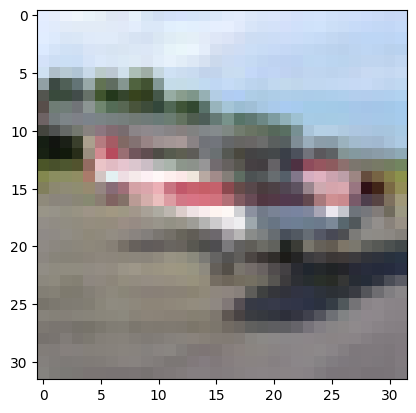

In [ ]:
show_image(dataset[222][0],dataset[222][1])

Label:  airplane (0)


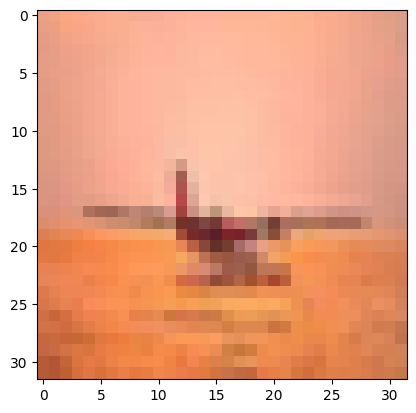

In [ ]:
show_image(*dataset[1099])

In [ ]:
random_seed=42
torch.manual_seed(random_seed);

In [ ]:
val_size = 5000
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset,[train_size, val_size],generator=torch.manual_seed(random_seed))
len(train_ds), len(val_ds)

(45000, 5000)

In [ ]:
batch_size=128
train_dl = DataLoader(train_ds,batch_size,shuffle=True,num_workers=4,pin_memory=True )
val_dl = DataLoader(val_ds, batch_size, num_workers=4, pin_memory=True)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
train_dl

In [ ]:
def show_images_batch(d1):
    for images, labels in d1:
        fig, ax= plt.subplots(figsize=(16,8))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(make_grid(images, nrow=16).permute(1,2,0))
        break # to stop loop otherwise 4500 images in batch size of 128 will print and is computationally expensive

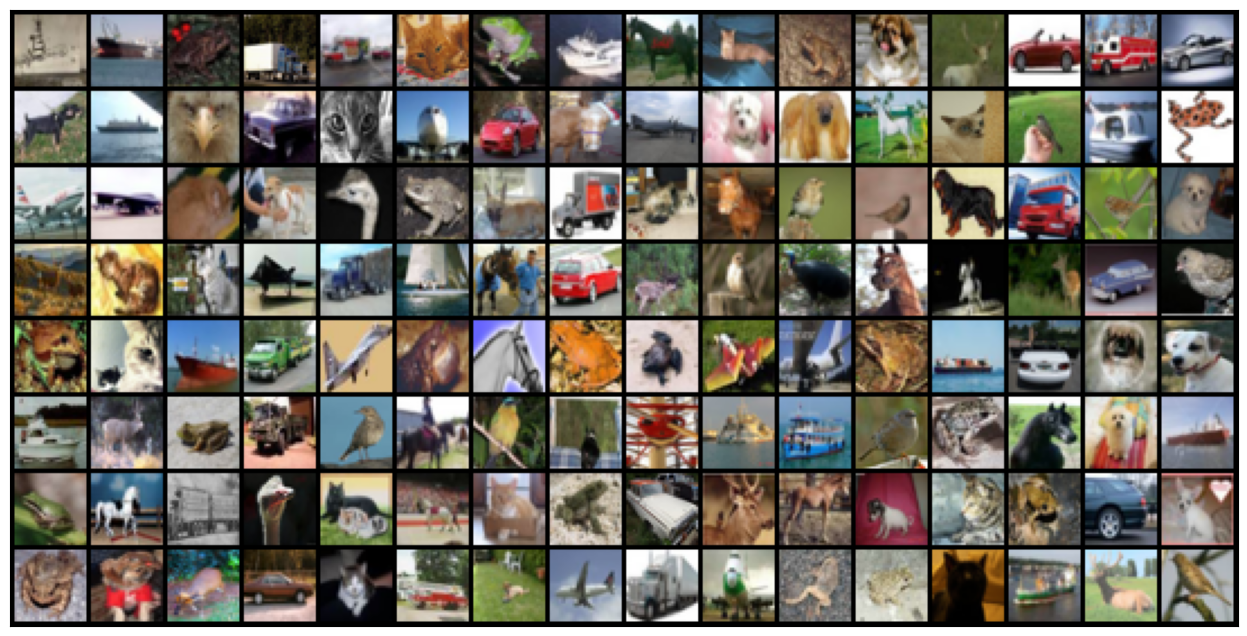

In [ ]:
show_images_batch(train_dl) # training data single batch images

In [ ]:
show_images_batch(val_dl) # validation data single batch images

NameError: name 'show_images_batch' is not defined

**Convolutional Neural Network**

In [ ]:
def apply_kernel(image, kernel):
    ri, ci = image.shape       # image dimensions
    rk, ck = kernel.shape      # kernel dimensions
    ro, co = ri-rk+1, ci-ck+1  # output dimensions, No padding and no striding
    output = torch.zeros([ro, co])
    for i in range(ro):
        for j in range(co):
            output[i,j] = torch.sum(image[i:i+rk,j:j+ck] * kernel)
    return output

In [ ]:
sample_image = torch.tensor([
    [4, 4, 3, 1, 0],
    [0, 0, 1, 4, 1],
    [4, 1, 3, 3, 4],
    [2, 0, 0, 3, 3],
    [3, 0, 0, 0, 1]
], dtype=torch.float32)

sample_kernel = torch.tensor([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=torch.float32) #blur filter

apply_kernel(sample_image, sample_kernel)

NameError: name 'torch' is not defined

In [1]:
import os
import shutil

# Path to the root of your Google Drive
drive_root = "/content/drive/MyDrive"

# Loop through all items in the root and delete
for item in os.listdir(drive_root):
    item_path = os.path.join(drive_root, item)
    try:
        if os.path.isfile(item_path) or os.path.islink(item_path):
            os.remove(item_path)
            print(f"Deleted file: {item}")
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)
            print(f"Deleted folder: {item}")
    except Exception as e:
        print(f"Failed to delete {item}: {e}")


Streaming output truncated to the last 5000 lines.
Deleted file: 2588_automobile.png
Deleted file: 18643_dog.png
Deleted file: 25841_frog.png
Deleted file: 28806_frog.png
Deleted file: 17562_frog.png
Deleted file: 9454_horse.png
Deleted file: 34480_truck.png
Deleted file: 31396_frog.png
Deleted file: 21494_dog.png
Deleted file: 16565_horse.png
Deleted file: 30698_dog.png
Deleted file: 34441_ship.png
Deleted file: 14016_truck.png
Deleted file: 10470_airplane.png
Deleted file: 562_ship.png
Deleted file: 20160_frog.png
Deleted file: 13872_dog.png
Deleted file: 3763_cat.png
Deleted file: 4631_automobile.png
Deleted file: 13499_dog.png
Deleted file: 13673_dog.png
Deleted file: 34567_airplane.png
Deleted file: 6252_frog.png
Deleted file: 12077_frog.png
Deleted file: 2220_ship.png
Deleted file: 13666_ship.png
Deleted file: 10370_automobile.png
Deleted file: 1498_horse.png
Deleted file: 1392_ship.png
Deleted file: 9109_ship.png
Deleted file: 18118_ship.png
Deleted file: 28183_automobile.png
De

In [3]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Set root directory of your Drive
drive_root = "/content/drive/MyDrive"

# List all items
items = os.listdir(drive_root)

# Print total count
print(f"Total items in Drive root: {len(items)}")

# (Optional) Print the items
for item in items:
    print("•", item)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total items in Drive root: 0
